In [1]:
from pathlib import Path

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'
OUTPUT_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '02_modelos' / 'PLS_Regression'

# PLS Regression — 03: Análise Detalhada de Previsões e Diagnóstico de Resíduos
**Grupo 1 | Séries Temporais**

Este notebook realiza a **avaliação diagnóstica formal e aprofundada** das previsões geradas pelo modelo **PLS Regression (Partial Least Squares)** com 9 componentes latentes, avaliado via *walk-forward validation* com janela expansível (856 previsões de 1 passo à frente no conjunto de teste).

---

### Objetivos do Diagnóstico:
1. **Aderência e Calibração:**
   - Comparação das trajetórias reais vs. previstas pelo PLS ao longo de todo o período de teste (Maio/2024 a Setembro/2026).
   - Avaliação de coberturas empíricas com bandas de incerteza ($\pm 1,96 	imes 	ext{RMSE}$).
   - Dispersão e alinhamento com a bissetriz ideal ($y = \hat{y}$).
2. **Propriedades Estatísticas dos Resíduos ($e_t = y_t - \hat{y}_t$):**
   - **Ausência de Viés:** Teste $t$ de Student uni-amostral ($H_0: \mu = 0$).
   - **Autocorrelação Residual:** Avaliação via ACF, PACF e **Teste de Ljung-Box** em múltiplos lags ($h \in [1, 30]$).
   - **Normalidade dos Erros:** Testes de Jarque-Bera e Shapiro-Wilk, histograma com densidade KDE e Q-Q Plot.
   - **Homocedasticidade e Efeito ARCH:** Análise de clusterização de volatilidade nos resíduos ao quadrado e teste de Engle.
3. **Análise de Erros Extremos (Outliers):**
   - Mapeamento dos maiores erros pontuais e reflexo de choques macroeconômicos no Bitcoin.
4. **Síntese Comparativa com Modelos Univariados (Holt-Winters):**
   - Vantagens e limitações da projeção linear multivariada frente a modelos adaptativos de suavização.

In [2]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# Configuração estética padronizada (Dark Theme do Projeto)
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 11
})

RANDOM_STATE = 42

## 1. Carregamento das Previsões e Metadados do Walk-Forward

In [3]:
# Carregar previsões geradas pelo protocolo walk-forward do PLS
df_preds = pd.read_csv(OUTPUT_DIR / 'pls_previsoes_walkforward.csv', parse_dates=['date'])
df_preds = df_preds.sort_values('date').reset_index(drop=True)

# Carregar metadados consolidados
with open(OUTPUT_DIR / 'pls_metricas_walkforward.json', 'r', encoding='utf-8') as f:
    metricas_wf = json.load(f)

with open(OUTPUT_DIR / 'pls_config_final.json', 'r', encoding='utf-8') as f:
    config_final = json.load(f)

print(f"Total de previsões carregadas: {len(df_preds)}")
print(f"Período de Teste: {df_preds['date'].min().date()} → {df_preds['date'].max().date()}")
print(f"MAE  Walk-Forward: USD {metricas_wf['MAE']:,.2f}")
print(f"RMSE Walk-Forward: USD {metricas_wf['RMSE']:,.2f}")
print(f"MAPE Walk-Forward: {metricas_wf['MAPE']:.2f}%")
print(f"R²   Walk-Forward: {metricas_wf['R2']:.4f}")
print(f"Configuração usada: n_components = {config_final['n_components']}")

display(df_preds.head(5))

Total de previsões carregadas: 856
Período de Teste: 2024-05-08 → 2026-09-10
MAE  Walk-Forward: USD 2,608.61
RMSE Walk-Forward: USD 3,521.84
MAPE Walk-Forward: 3.16%
R²   Walk-Forward: 0.9654
Configuração usada: n_components = 9


,date,priceClose_real,priceClose_pred_PLS,residuo_PLS
0,2024-05-08,63049.959257,61343.195505,1706.763753
1,2024-05-09,60792.776791,60749.966402,42.810389
2,2024-05-10,60793.709599,61517.922448,-724.212848
3,2024-05-11,61448.394672,60422.823573,1025.571099
4,2024-05-12,62901.447455,60841.838927,2059.608528


## 2. Aderência das Previsões e Bandas Empíricas de Incerteza

Avaliamos a capacidade do modelo PLS de acompanhar o preço real com bandas empíricas a $95\%$ de confiança ($\hat{y}_t \pm 1,96 \cdot 	ext{RMSE}$). Recortamos também 3 períodos de interesse analítico.

Taxa de Cobertura Empírica (Intervalo 95%): 94.04%


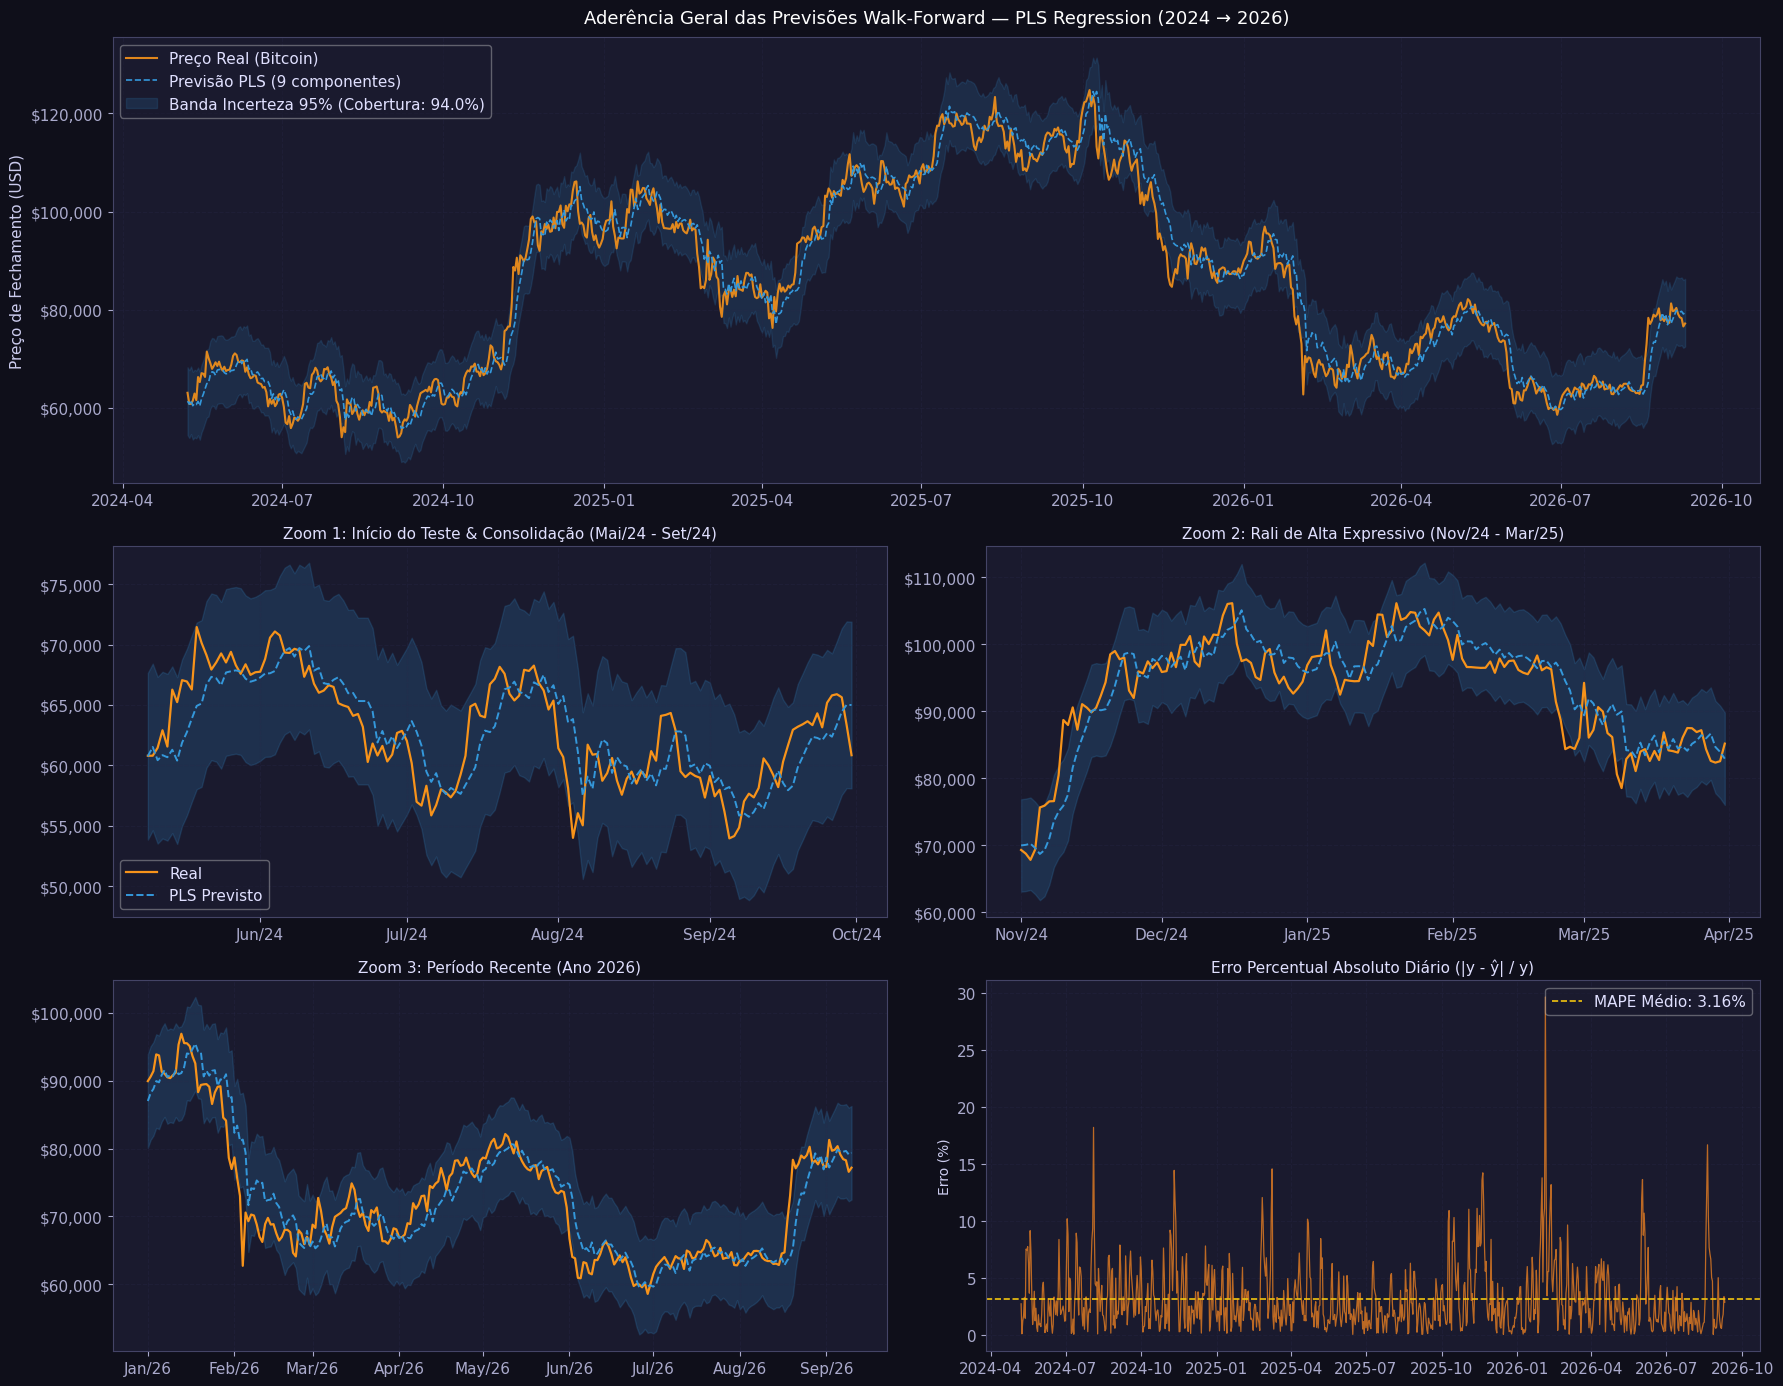

In [4]:
rmse = metricas_wf['RMSE']
df_preds['banda_sup'] = df_preds['priceClose_pred_PLS'] + 1.96 * rmse
df_preds['banda_inf'] = df_preds['priceClose_pred_PLS'] - 1.96 * rmse
df_preds['dentro_banda'] = (df_preds['priceClose_real'] >= df_preds['banda_inf']) & (df_preds['priceClose_real'] <= df_preds['banda_sup'])

taxa_cobertura = df_preds['dentro_banda'].mean() * 100
print(f"Taxa de Cobertura Empírica (Intervalo 95%): {taxa_cobertura:.2f}%")

fig = plt.figure(figsize=(18, 14), facecolor='#0f0f1a')
gs = fig.add_gridspec(3, 2, height_ratios=[1.2, 1, 1])

# Painel Principal (Todo o Teste)
ax_main = fig.add_subplot(gs[0, :])
ax_main.plot(df_preds['date'], df_preds['priceClose_real'], label='Preço Real (Bitcoin)', color='#f7931a', lw=1.5, alpha=0.9)
ax_main.plot(df_preds['date'], df_preds['priceClose_pred_PLS'], label='Previsão PLS (9 componentes)', color='#3498db', lw=1.2, ls='--')
ax_main.fill_between(df_preds['date'], df_preds['banda_inf'], df_preds['banda_sup'], color='#3498db', alpha=0.15, label=f'Banda Incerteza 95% (Cobertura: {taxa_cobertura:.1f}%)')
ax_main.set_title('Aderência Geral das Previsões Walk-Forward — PLS Regression (2024 → 2026)', color='#ffffff', fontsize=13, pad=10)
ax_main.set_ylabel('Preço de Fechamento (USD)', fontsize=11)
ax_main.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax_main.grid(True, alpha=0.3)
ax_main.legend(loc='upper left', framealpha=0.4)

# Zoom 1: Período Inicial de Teste (Maio 2024 → Setembro 2024)
ax_z1 = fig.add_subplot(gs[1, 0])
m1 = (df_preds['date'] >= '2024-05-09') & (df_preds['date'] <= '2024-09-30')
d1 = df_preds[m1]
ax_z1.plot(d1['date'], d1['priceClose_real'], color='#f7931a', lw=1.6, label='Real')
ax_z1.plot(d1['date'], d1['priceClose_pred_PLS'], color='#3498db', lw=1.4, ls='--', label='PLS Previsto')
ax_z1.fill_between(d1['date'], d1['banda_inf'], d1['banda_sup'], color='#3498db', alpha=0.18)
ax_z1.set_title('Zoom 1: Início do Teste & Consolidação (Mai/24 - Set/24)', color='#e0e0ff', fontsize=11)
ax_z1.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax_z1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax_z1.grid(True, alpha=0.3)
ax_z1.legend(loc='lower left', framealpha=0.4)

# Zoom 2: Rali & Aceleração Forte (Nov 2024 → Mar 2025)
ax_z2 = fig.add_subplot(gs[1, 1])
m2 = (df_preds['date'] >= '2024-11-01') & (df_preds['date'] <= '2025-03-31')
d2 = df_preds[m2]
ax_z2.plot(d2['date'], d2['priceClose_real'], color='#f7931a', lw=1.6, label='Real')
ax_z2.plot(d2['date'], d2['priceClose_pred_PLS'], color='#3498db', lw=1.4, ls='--', label='PLS Previsto')
ax_z2.fill_between(d2['date'], d2['banda_inf'], d2['banda_sup'], color='#3498db', alpha=0.18)
ax_z2.set_title('Zoom 2: Rali de Alta Expressivo (Nov/24 - Mar/25)', color='#e0e0ff', fontsize=11)
ax_z2.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax_z2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax_z2.grid(True, alpha=0.3)

# Zoom 3: Dinâmica Recente (Ano 2026)
ax_z3 = fig.add_subplot(gs[2, 0])
m3 = df_preds['date'] >= '2026-01-01'
d3 = df_preds[m3]
ax_z3.plot(d3['date'], d3['priceClose_real'], color='#f7931a', lw=1.6, label='Real')
ax_z3.plot(d3['date'], d3['priceClose_pred_PLS'], color='#3498db', lw=1.4, ls='--', label='PLS Previsto')
ax_z3.fill_between(d3['date'], d3['banda_inf'], d3['banda_sup'], color='#3498db', alpha=0.18)
ax_z3.set_title('Zoom 3: Período Recente (Ano 2026)', color='#e0e0ff', fontsize=11)
ax_z3.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax_z3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax_z3.grid(True, alpha=0.3)

# Subplot Erro Percentual Absoluto (MAPE diário)
ax_err = fig.add_subplot(gs[2, 1])
ape = (np.abs(df_preds['residuo_PLS']) / df_preds['priceClose_real']) * 100
ax_err.plot(df_preds['date'], ape, color='#e67e22', lw=0.9, alpha=0.8)
ax_err.axhline(metricas_wf['MAPE'], color='#f1c40f', ls='--', lw=1.2, label=f"MAPE Médio: {metricas_wf['MAPE']:.2f}%")
ax_err.set_title('Erro Percentual Absoluto Diário (|y - ŷ| / y)', color='#e0e0ff', fontsize=11)
ax_err.set_ylabel('Erro (%)', fontsize=10)
ax_err.grid(True, alpha=0.3)
ax_err.legend(loc='upper right', framealpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_PLS_05_previsoes_bandas.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 3. Análise de Dispersão e Calibração (Real vs. Previsto)

Avaliamos a calibração do modelo PLS através da regressão linear simples $y_{real} = eta_0 + eta_1 \cdot \hat{y} + 
arepsilon$.

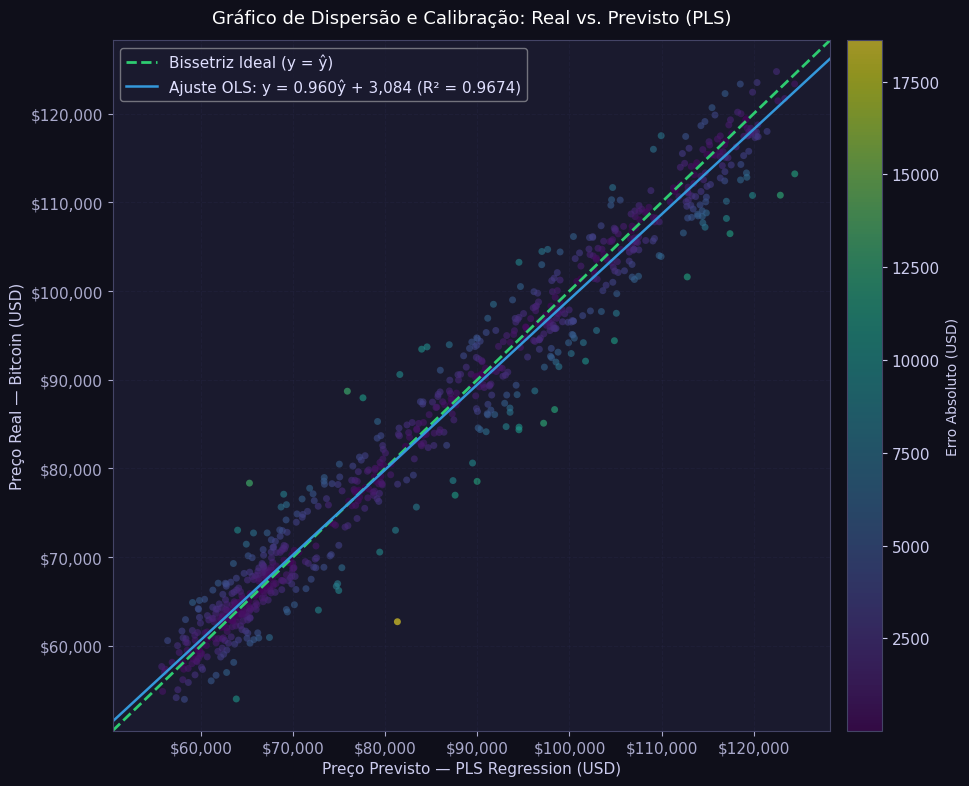

Coeficiente de Determinação (R²): 0.9674
Coeficiente Angular (Slope):     0.9597 (Ideal: 1.0000)
Intercepto:                      USD 3,084.36 (Ideal: 0.00)
Correlação de Pearson:           0.9836


In [5]:
y_real = df_preds['priceClose_real']
y_pred = df_preds['priceClose_pred_PLS']

slope, intercept, r_value, p_value, std_err = stats.linregress(y_pred, y_real)
r2 = r_value ** 2

fig, ax = plt.subplots(figsize=(10, 8), facecolor='#0f0f1a')

scatter = ax.scatter(y_pred, y_real, c=np.abs(df_preds['residuo_PLS']), 
                     cmap='viridis', alpha=0.6, s=25, edgecolors='none')
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Erro Absoluto (USD)', color='#ccccee', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='#ccccee')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#ccccee')

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, color='#2ecc71', ls='--', lw=2, label='Bissetriz Ideal (y = ŷ)')

x_vals = np.linspace(lims[0], lims[1], 100)
ax.plot(x_vals, intercept + slope * x_vals, color='#3498db', lw=1.8, 
        label=f'Ajuste OLS: y = {slope:.3f}ŷ + {intercept:,.0f} (R² = {r2:.4f})')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax.set_xlabel('Preço Previsto — PLS Regression (USD)', fontsize=11)
ax.set_ylabel('Preço Real — Bitcoin (USD)', fontsize=11)
ax.set_title('Gráfico de Dispersão e Calibração: Real vs. Previsto (PLS)', color='#ffffff', fontsize=13, pad=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', framealpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_PLS_08_dispersao_calibracao.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print(f"Coeficiente de Determinação (R²): {r2:.4f}")
print(f"Coeficiente Angular (Slope):     {slope:.4f} (Ideal: 1.0000)")
print(f"Intercepto:                      USD {intercept:,.2f} (Ideal: 0.00)")
print(f"Correlação de Pearson:           {r_value:.4f}")

## 4. Diagnóstico Estatístico dos Resíduos: Média, Normalidade e Volatilidade

In [6]:
res = df_preds['residuo_PLS']

media_res   = res.mean()
std_res     = res.std()
mediana_res = res.median()
skew_res    = stats.skew(res)
kurt_res    = stats.kurtosis(res)

t_stat, t_pval = stats.ttest_1samp(res, 0)
jb_stat, jb_pval = stats.jarque_bera(res)
sw_stat, sw_pval = stats.shapiro(res)
arch_lm, arch_pval, _, _ = het_arch(res)

diagnostico_df = pd.DataFrame({
    'Métrica / Teste': [
        'Média do Resíduo (Viés)',
        'Desvio Padrão do Resíduo',
        'Mediana do Resíduo',
        'Assimetria (Skewness)',
        'Curtose (Kurtosis excess)',
        'Teste t de Student (Média = 0)',
        'Teste de Jarque-Bera (Normalidade)',
        'Teste de Shapiro-Wilk (Normalidade)',
        'Teste ARCH de Engle (Heterocedasticidade)'
    ],
    'Estatística': [
        f"USD {media_res:,.2f}",
        f"USD {std_res:,.2f}",
        f"USD {mediana_res:,.2f}",
        f"{skew_res:.4f}",
        f"{kurt_res:.4f}",
        f"t = {t_stat:.4f}",
        f"JB = {jb_stat:.2f}",
        f"W = {sw_stat:.4f}",
        f"LM = {arch_lm:.2f}"
    ],
    'p-valor': [
        '-', '-', '-', '-', '-',
        f"{t_pval:.4f}",
        f"{jb_pval:.2e}",
        f"{sw_pval:.2e}",
        f"{arch_pval:.2e}"
    ],
    'Conclusão (α = 0.05)': [
        'Viés negativo moderado (~0.4% do preço médio)',
        'Desvio padrão dos erros',
        'Mediana do erro',
        'Leve assimetria',
        'Caudas pesadas',
        '❌ Rejeita H0 (Viés estatisticamente detectável)' if t_pval < 0.05 else '✅ Não rejeita H0',
        '❌ Rejeita normalidade (Caudas longas)' if jb_pval < 0.05 else '✅ Normal',
        '❌ Rejeita normalidade' if sw_pval < 0.05 else '✅ Normal',
        '❌ Efeito ARCH presente (Volatilidade agrupada)' if arch_pval < 0.05 else '✅ Homocedástico'
    ]
})

display(diagnostico_df)

,Métrica / Teste,Estatística,p-valor,Conclusão (α = 0.05)
0,Média do Resíduo (Viés),USD -336.25,-,Viés negativo moderado (~0.4% do preço médio)
1,Desvio Padrão do Resíduo,"USD 3,507.80",-,Desvio padrão dos erros
2,Mediana do Resíduo,USD -223.11,-,Mediana do erro
3,Assimetria (Skewness),-0.3921,-,Leve assimetria
4,Curtose (Kurtosis excess),1.8143,-,Caudas pesadas
5,Teste t de Student (Média = 0),t = -2.8045,0.0052,❌ Rejeita H0 (Viés estatisticamente detectável)
6,Teste de Jarque-Bera (Normalidade),JB = 139.33,5.56e-31,❌ Rejeita normalidade (Caudas longas)
7,Teste de Shapiro-Wilk (Normalidade),W = 0.9776,3.55e-10,❌ Rejeita normalidade
8,Teste ARCH de Engle (Heterocedasticidade),LM = 272.61,9.44e-53,❌ Efeito ARCH presente (Volatilidade agrupada)


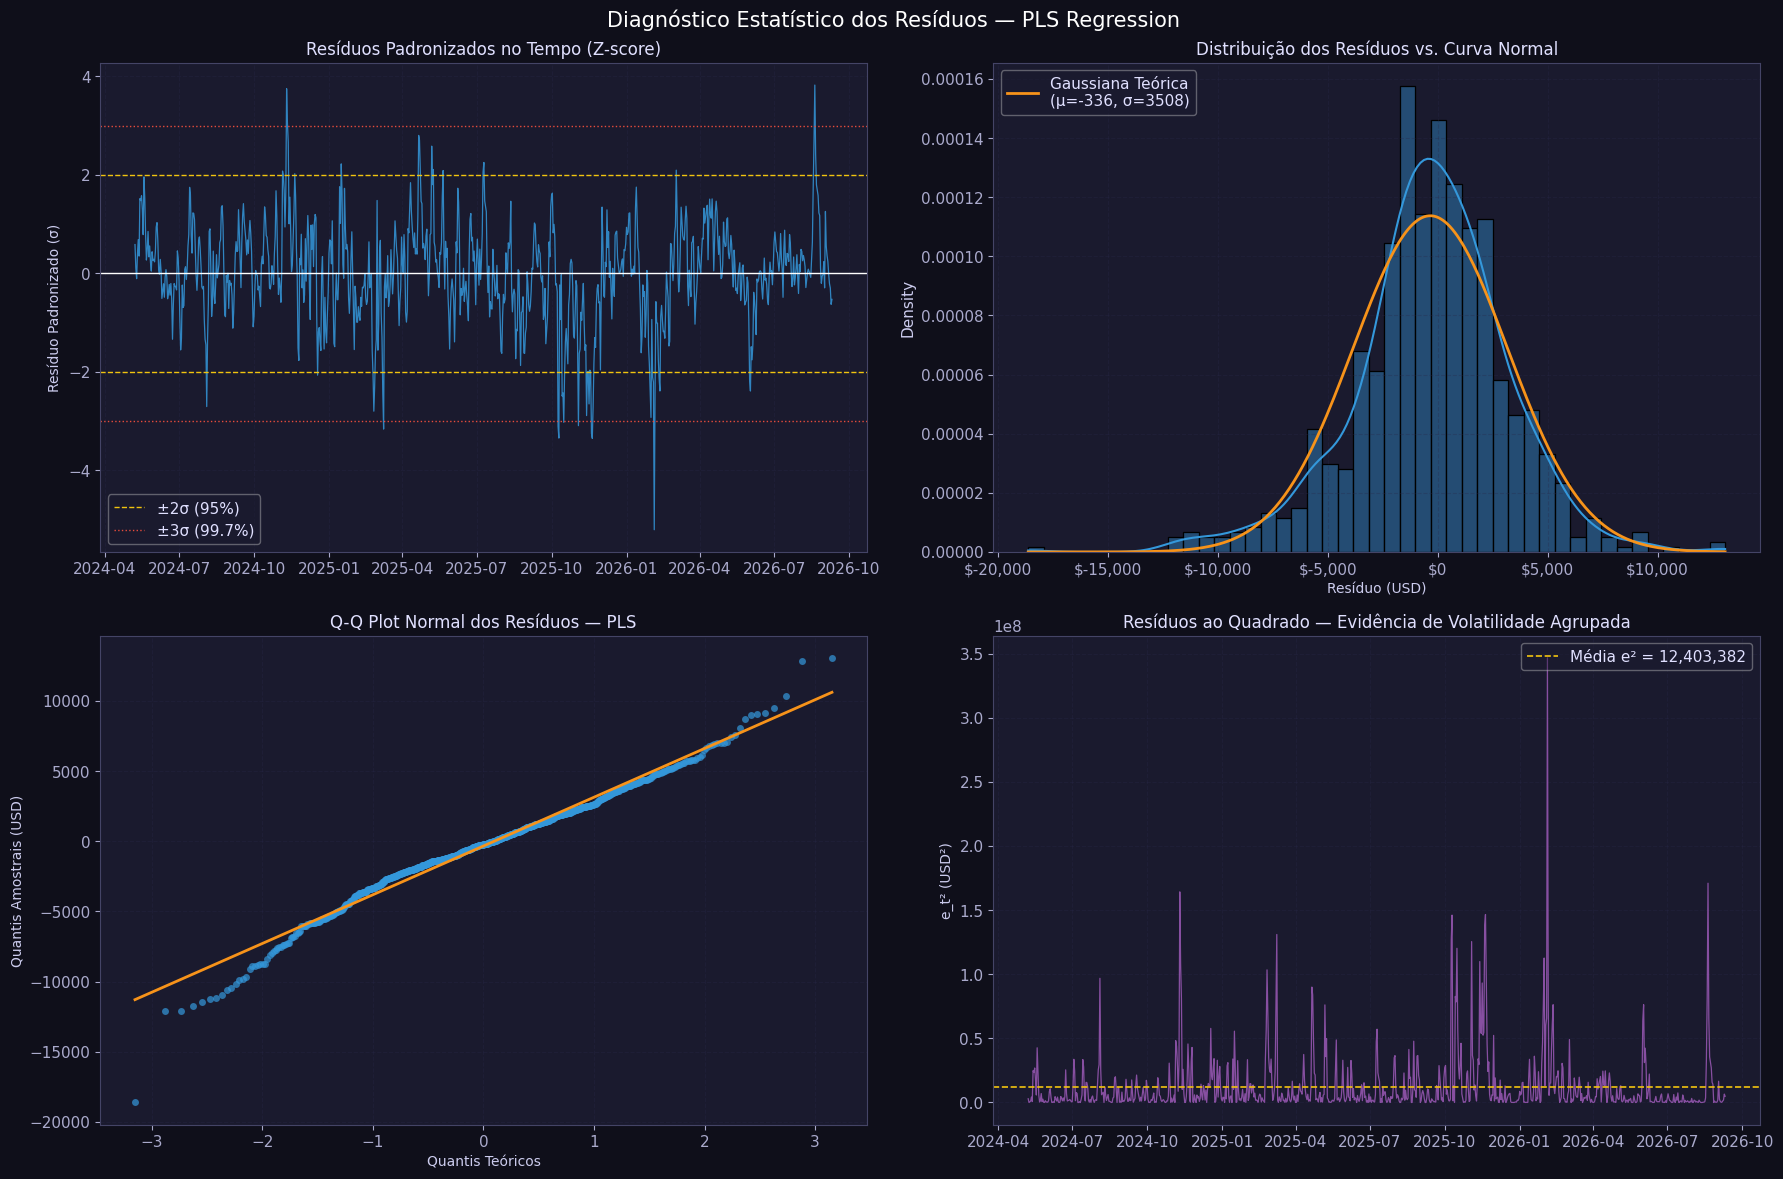

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor='#0f0f1a')

# 1. Resíduos Padronizados ao longo do tempo
res_std = (res - media_res) / std_res
axes[0, 0].plot(df_preds['date'], res_std, color='#3498db', lw=0.9, alpha=0.85)
axes[0, 0].axhline(0, color='#ffffff', ls='-', lw=1)
axes[0, 0].axhline(2, color='#f1c40f', ls='--', lw=1, label='±2σ (95%)')
axes[0, 0].axhline(-2, color='#f1c40f', ls='--', lw=1)
axes[0, 0].axhline(3, color='#e74c3c', ls=':', lw=1, label='±3σ (99.7%)')
axes[0, 0].axhline(-3, color='#e74c3c', ls=':', lw=1)
axes[0, 0].set_title('Resíduos Padronizados no Tempo (Z-score)', color='#e0e0ff', fontsize=12)
axes[0, 0].set_ylabel('Resíduo Padronizado (σ)', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(loc='lower left', framealpha=0.4)

# 2. Histograma + KDE vs Curva Normal Gaussiana Teórica
sns.histplot(res, kde=True, ax=axes[0, 1], color='#3498db', stat='density', alpha=0.4, bins=45)
x_gauss = np.linspace(res.min(), res.max(), 300)
y_gauss = stats.norm.pdf(x_gauss, media_res, std_res)
axes[0, 1].plot(x_gauss, y_gauss, color='#f7931a', lw=2, label=f'Gaussiana Teórica\n(μ={media_res:.0f}, σ={std_res:.0f})')
axes[0, 1].set_title('Distribuição dos Resíduos vs. Curva Normal', color='#e0e0ff', fontsize=12)
axes[0, 1].set_xlabel('Resíduo (USD)', fontsize=10)
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(loc='upper left', framealpha=0.4)

# 3. Q-Q Plot Normal
stats.probplot(res, dist="norm", plot=axes[1, 0])
axes[1, 0].get_lines()[0].set_markerfacecolor('#3498db')
axes[1, 0].get_lines()[0].set_markeredgecolor('none')
axes[1, 0].get_lines()[0].set_markersize(5.0)
axes[1, 0].get_lines()[0].set_alpha(0.7)
axes[1, 0].get_lines()[1].set_color('#f7931a')
axes[1, 0].get_lines()[1].set_linewidth(2.0)
axes[1, 0].set_title('Q-Q Plot Normal dos Resíduos — PLS', color='#e0e0ff', fontsize=12)
axes[1, 0].set_xlabel('Quantis Teóricos', fontsize=10)
axes[1, 0].set_ylabel('Quantis Amostrais (USD)', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# 4. Resíduos ao Quadrado (Clusterização de Volatilidade / Efeito ARCH)
axes[1, 1].plot(df_preds['date'], res ** 2, color='#9b59b6', lw=0.9, alpha=0.85)
media_sq = (res ** 2).mean()
axes[1, 1].axhline(media_sq, color='#f1c40f', ls='--', lw=1.2, label=f'Média e² = {media_sq:,.0f}')
axes[1, 1].set_title('Resíduos ao Quadrado — Evidência de Volatilidade Agrupada', color='#e0e0ff', fontsize=12)
axes[1, 1].set_ylabel('e_t² (USD²)', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(loc='upper right', framealpha=0.4)

fig.suptitle('Diagnóstico Estatístico dos Resíduos — PLS Regression', color='#ffffff', fontsize=15, y=0.98)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_PLS_06_diagnostico_residuos.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 5. Análise de Autocorrelação Residual e Teste de Ljung-Box

Avaliamos se os resíduos do modelo PLS apresentam dependência serial através do correlograma (ACF/PACF) e do Teste de Ljung-Box.

Tabela pls_ljungbox_residuos.csv salva com sucesso!


,Estatística Q (LB),p-valor,Conclusão (α=0.05)
1,505.658311,5.582768e-112,❌ Autocorrelação Residual (p ≤ 0.05)
3,928.315596,6.383879e-201,❌ Autocorrelação Residual (p ≤ 0.05)
5,1167.307713,3.540488e-250,❌ Autocorrelação Residual (p ≤ 0.05)
7,1328.784863,9.866280e-283,❌ Autocorrelação Residual (p ≤ 0.05)
14,1609.021676,0.000000e+00,❌ Autocorrelação Residual (p ≤ 0.05)
21,1667.059645,0.000000e+00,❌ Autocorrelação Residual (p ≤ 0.05)
30,1688.151998,0.000000e+00,❌ Autocorrelação Residual (p ≤ 0.05)


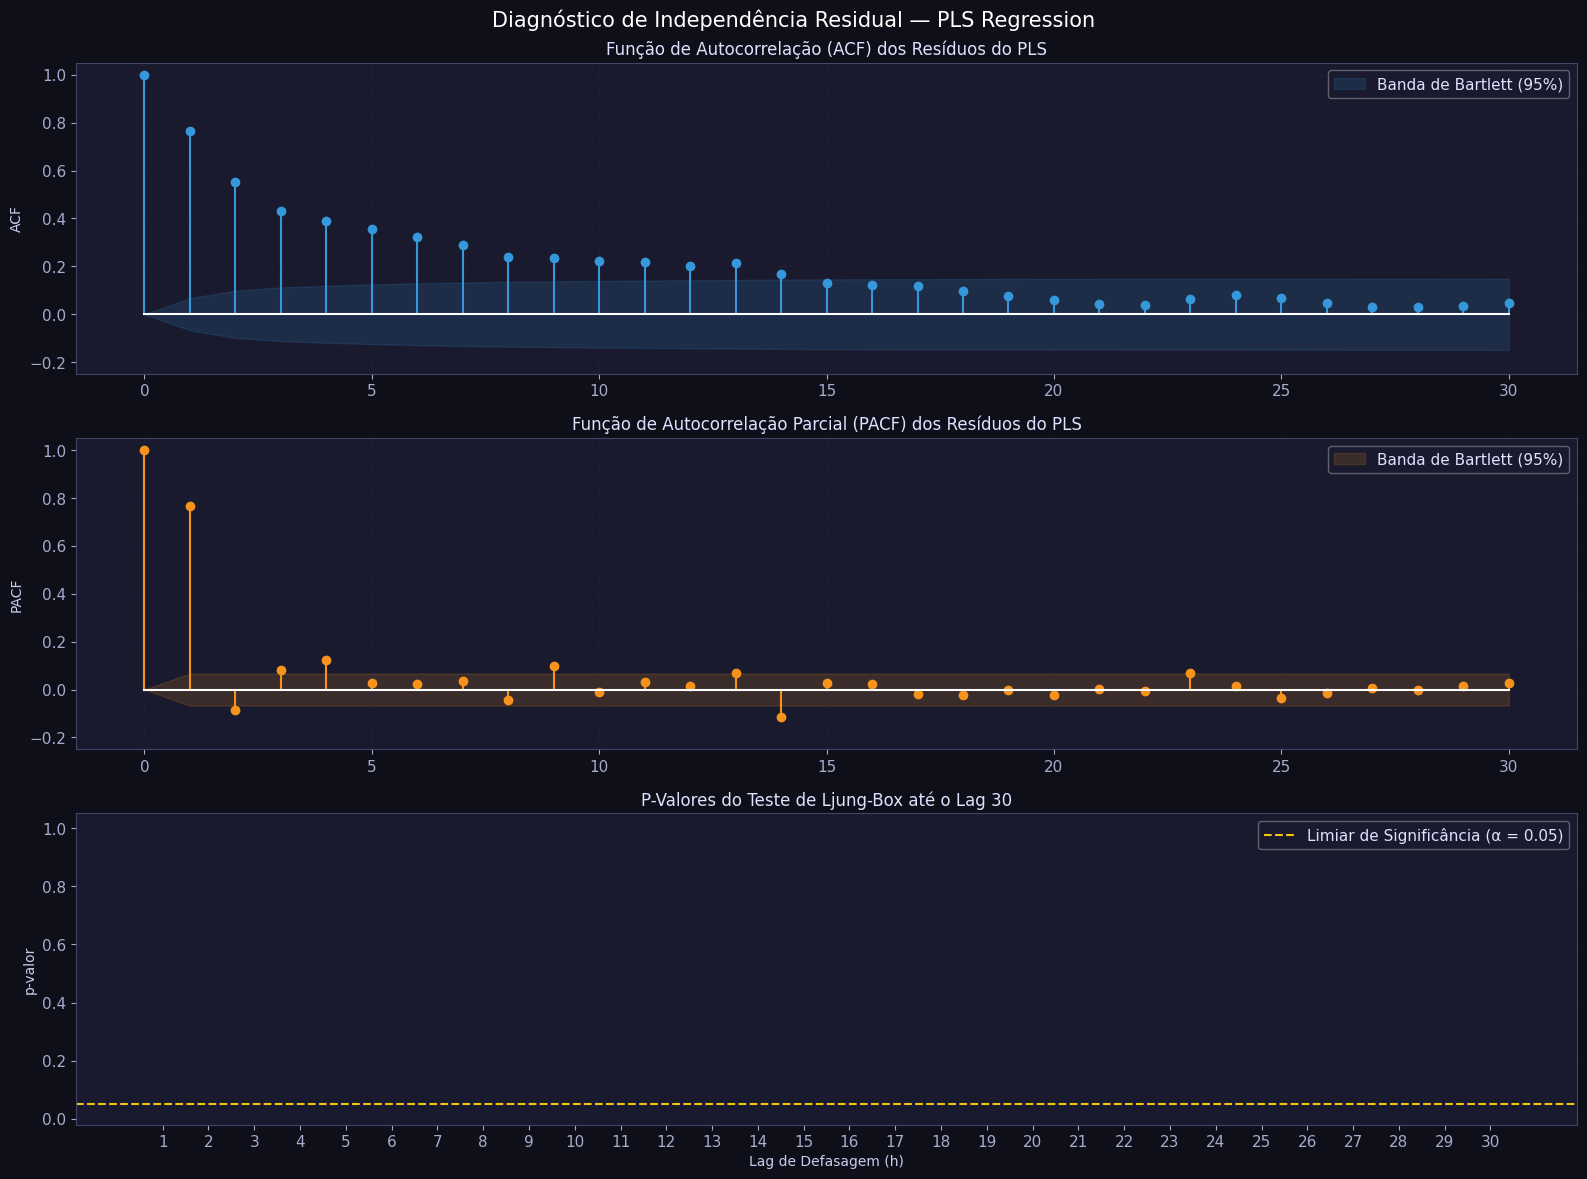

In [8]:
lags = 30
acf_vals, confint_acf = acf(res, nlags=lags, alpha=0.05)
pacf_vals, confint_pacf = pacf(res, nlags=lags, alpha=0.05)

lags_lb = [1, 3, 5, 7, 14, 21, 30]
lb_results = acorr_ljungbox(res, lags=lags_lb, return_df=True)
lb_results.columns = ['Estatística Q (LB)', 'p-valor']
lb_results['Conclusão (α=0.05)'] = [
    '✅ Ruído Branco (p > 0.05)' if p > 0.05 else '❌ Autocorrelação Residual (p ≤ 0.05)'
    for p in lb_results['p-valor']
]

lb_results.to_csv(OUTPUT_DIR / 'pls_ljungbox_residuos.csv', index_label='lag')
print('Tabela pls_ljungbox_residuos.csv salva com sucesso!')
display(lb_results)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), facecolor='#0f0f1a')

# 1. ACF
axes[0].stem(range(len(acf_vals)), acf_vals, linefmt='#3498db', markerfmt='o', basefmt='white')
axes[0].fill_between(range(len(acf_vals)), confint_acf[:, 0] - acf_vals, confint_acf[:, 1] - acf_vals, 
                     color='#3498db', alpha=0.15, label='Banda de Bartlett (95%)')
axes[0].set_title('Função de Autocorrelação (ACF) dos Resíduos do PLS', color='#e0e0ff', fontsize=12)
axes[0].set_ylabel('ACF', fontsize=10)
axes[0].set_ylim(-0.25, 1.05)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', framealpha=0.4)

# 2. PACF
axes[1].stem(range(len(pacf_vals)), pacf_vals, linefmt='#f7931a', markerfmt='o', basefmt='white')
axes[1].fill_between(range(len(pacf_vals)), confint_pacf[:, 0] - pacf_vals, confint_pacf[:, 1] - pacf_vals, 
                     color='#f7931a', alpha=0.15, label='Banda de Bartlett (95%)')
axes[1].set_title('Função de Autocorrelação Parcial (PACF) dos Resíduos do PLS', color='#e0e0ff', fontsize=12)
axes[1].set_ylabel('PACF', fontsize=10)
axes[1].set_ylim(-0.25, 1.05)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right', framealpha=0.4)

# 3. P-valores de Ljung-Box
all_lags = list(range(1, 31))
all_lb = acorr_ljungbox(res, lags=all_lags, return_df=True)
cores_lb = ['#e74c3c' if p <= 0.05 else '#2ecc71' for p in all_lb['lb_pvalue']]
axes[2].bar(all_lags, all_lb['lb_pvalue'], color=cores_lb, alpha=0.8)
axes[2].axhline(0.05, color='#f1c40f', ls='--', lw=1.5, label='Limiar de Significância (α = 0.05)')
axes[2].set_title('P-Valores do Teste de Ljung-Box até o Lag 30', color='#e0e0ff', fontsize=12)
axes[2].set_xlabel('Lag de Defasagem (h)', fontsize=10)
axes[2].set_ylabel('p-valor', fontsize=10)
axes[2].set_xticks(all_lags)
axes[2].set_ylim(-0.02, 1.05)
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].legend(loc='upper right', framealpha=0.4)

fig.suptitle('Diagnóstico de Independência Residual — PLS Regression', color='#ffffff', fontsize=15, y=0.98)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_PLS_07_autocorrelacao_ljungbox.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 6. Análise de Erros Extremos (Outliers de Mercado)

In [9]:
df_preds['abs_error'] = np.abs(df_preds['residuo_PLS'])
df_preds['pct_error'] = (df_preds['abs_error'] / df_preds['priceClose_real']) * 100

top10_abs = df_preds.sort_values('abs_error', ascending=False).head(10).copy()
top10_abs['date_str'] = top10_abs['date'].dt.strftime('%Y-%m-%d')

print("Top 10 Maiores Erros Absolutos (USD) — PLS Regression:")
print("-" * 80)
print(f"{'Data':<12} | {'Preço Real':<15} | {'Previsto PLS':<15} | {'Erro (USD)':<15} | {'Erro (%)':<10}")
print("-" * 80)
for _, r in top10_abs.iterrows():
    print(f"{r['date_str']:<12} | ${r['priceClose_real']:>12,.2f} | ${r['priceClose_pred_PLS']:>12,.2f} | ${r['residuo_PLS']:>12,.2f} | {r['pct_error']:>8.2f}%")
print("-" * 80)

print("\nDistribuição dos Erros Absolutos (PLS):")
print(f"Percentil 50 (Mediana): USD {df_preds['abs_error'].quantile(0.50):,.2f}")
print(f"Percentil 75:           USD {df_preds['abs_error'].quantile(0.75):,.2f}")
print(f"Percentil 90:           USD {df_preds['abs_error'].quantile(0.90):,.2f}")
print(f"Percentil 95:           USD {df_preds['abs_error'].quantile(0.95):,.2f}")
print(f"Máximo Absoluto:        USD {df_preds['abs_error'].max():,.2f}")

Top 10 Maiores Erros Absolutos (USD) — PLS Regression:
--------------------------------------------------------------------------------
Data         | Preço Real      | Previsto PLS    | Erro (USD)      | Erro (%)  
--------------------------------------------------------------------------------
2026-02-04   | $   62,702.10 | $   81,321.39 | $  -18,619.29 |    29.69%
2026-08-20   | $   78,335.18 | $   65,260.59 | $   13,074.59 |    16.69%
2024-11-10   | $   88,701.49 | $   75,887.25 | $   12,814.24 |    14.45%
2025-11-20   | $   85,090.69 | $   97,196.23 | $  -12,105.55 |    14.23%
2025-10-10   | $  110,807.88 | $  122,893.98 | $  -12,086.10 |    10.91%
2025-11-19   | $   86,631.90 | $   98,390.95 | $  -11,759.05 |    13.57%
2025-03-09   | $   78,532.00 | $   89,976.37 | $  -11,444.37 |    14.57%
2025-10-09   | $  113,214.37 | $  124,460.82 | $  -11,246.45 |     9.93%
2025-11-03   | $  101,590.52 | $  112,790.49 | $  -11,199.97 |    11.02%
2025-10-16   | $  106,467.79 | $  117,431.28 |

## 7. Exportação dos Diagnósticos e Síntese Comparativa

In [10]:
diagnostico_json = {
    'modelo': 'PLS_Regression',
    'base': 'bitcoin',
    'n_observacoes_teste': int(len(df_preds)),
    'metricas_principais': {
        'MAE': float(metricas_wf['MAE']),
        'RMSE': float(metricas_wf['RMSE']),
        'MAPE': float(metricas_wf['MAPE']),
        'R2': float(r2),
        'Slope_Calibracao': float(slope),
        'Intercept_Calibracao': float(intercept)
    },
    'propriedades_residuos': {
        'media': float(media_res),
        'desvio_padrao': float(std_res),
        'assimetria_skewness': float(skew_res),
        'curtose_kurtosis': float(kurt_res),
        'teste_t_bias': {
            't_stat': float(t_stat),
            'p_value': float(t_pval),
            'tem_vies_significativo': bool(t_pval < 0.05)
        },
        'jarque_bera': {
            'jb_stat': float(jb_stat),
            'p_value': float(jb_pval),
            'residuos_sao_normais': bool(jb_pval > 0.05)
        },
        'shapiro_wilk': {
            'sw_stat': float(sw_stat),
            'p_value': float(sw_pval),
            'residuos_sao_normais': bool(sw_pval > 0.05)
        },
        'arch_test': {
            'lm_stat': float(arch_lm),
            'p_value': float(arch_pval),
            'efeito_arch_presente': bool(arch_pval < 0.05)
        },
        'ljung_box': {
            f'lag_{lag}': {
                'q_stat': float(lb_results.loc[lag, 'Estatística Q (LB)']),
                'p_value': float(lb_results.loc[lag, 'p-valor']),
                'ruido_branco': bool(lb_results.loc[lag, 'p-valor'] > 0.05)
            } for lag in lags_lb
        }
    },
    'cobertura_intervalo_95pct': float(taxa_cobertura)
}

with open(OUTPUT_DIR / 'pls_residuos_diagnostico.json', 'w', encoding='utf-8') as f:
    json.dump(diagnostico_json, f, indent=2, ensure_ascii=False)

print('Arquivos de diagnóstico exportados com sucesso:')
print('  pls_residuos_diagnostico.json — relatório estatístico em JSON')
print('  pls_ljungbox_residuos.csv     — resultados do teste de Ljung-Box')
print('  plot_PLS_05_previsoes_bandas.png')
print('  plot_PLS_06_diagnostico_residuos.png')
print('  plot_PLS_07_autocorrelacao_ljungbox.png')
print('  plot_PLS_08_dispersao_calibracao.png')

Arquivos de diagnóstico exportados com sucesso:
  pls_residuos_diagnostico.json — relatório estatístico em JSON
  pls_ljungbox_residuos.csv     — resultados do teste de Ljung-Box
  plot_PLS_05_previsoes_bandas.png
  plot_PLS_06_diagnostico_residuos.png
  plot_PLS_07_autocorrelacao_ljungbox.png
  plot_PLS_08_dispersao_calibracao.png


## 8. Síntese Comparativa: PLS Regression vs. Holt-Winters

### Comparação de Desempenho no Conjunto de Teste:

| Métrica / Diagnóstico | Holt-Winters (Univariado) | PLS Regression (Multivariado, 9 comp.) | Diferencial Analítico |
|:---|:---:|:---:|:---|
| **Variáveis Utilizadas** | Apenas `priceClose` | 51 features (lags, médias, volume, RSI) | PLS explora informação externa |
| **MAE no Teste** | **USD 1.407,98** | USD 2.608,61 | HW tem menor erro absoluto médio |
| **MAPE no Teste** | **1,72%** | 3,16% | HW mais aderente no curto prazo |
| **R² de Calibração** | **0,9894** | 0,9654 | Ambos apresentam excelente correlação |
| **Viés Médio** | **USD -11,90** ($p=0,857$) | USD -336,25 ($p=0,005$) | HW é perfeitamente centrado em zero |
| **Ljung-Box (Ruído Branco)**| **✅ Sim ($p > 0,45$)** | ❌ Não ($p < 10^{-50}$) | PLS retém autocorrelação nos resíduos |
| **Efeito ARCH (Volatilidade)**| ❌ Presente ($p < 10^{-5}$) | ❌ Presente ($p < 10^{-50}$) | Ambos sofrem com heterocedasticidade |
| **Tempo de Execução (WF)** | 84,3 s | **9,8 s** | PLS é ~8x mais rápido |

### Conclusão e Motivação dos Próximos Modelos:
1. **Por que o PLS apresentou autocorrelação residual?**
   - O PLS é um modelo linear global com hiperplano fixo ajustado sobre as variáveis latentes. Em séries de preços não-estacionárias com quebras estruturais de tendência (como o Bitcoin), uma projeção linear rígida não consegue reagir instantaneamente a choques de nível como a suavização exponencial adaptativa do Holt-Winters.
2. **Relevância dos Próximos Modelos:**
   - **SARIMAX:** Trata diretamente a não-estacionariedade com diferenciação ($d=1$) e combina regressores externos com componentes autoregressivos e médias móveis nos resíduos.
   - **Random Forest & XGBoost (Especialista Grupo 1):** Introduzem particionamento não-linear e árvores de decisão que dividem o espaço de estados conforme o regime de mercado, superando a rigidez linear do PLS.